In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'StudentID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['Alice','Bob','Charlie','David','Eva',
             'Frank','Grace','Hannah','Ian','Jack'],
    # 100 is an outlier and NaN is missing value
    'Age': [15,16,15,16,15,np.nan,17,16,100,15],
    'Gender': ['F','M','M','M','F','M','F','F','M','F'],
    # 200 is an outlier
    'MathScore': [85,90,78,92,88,75,95,89,200,85],
    'EnglishScore': [78,85,np.nan,80,82,77,90,84,70,88],
    'ScienceScore': [92,88,85,95,90,78,93,87,89,np.nan]
}
df = pd.DataFrame(data)#Converts dictionary into table format.
print(df)

   StudentID     Name    Age Gender  MathScore  EnglishScore  ScienceScore
0          1    Alice   15.0      F         85          78.0          92.0
1          2      Bob   16.0      M         90          85.0          88.0
2          3  Charlie   15.0      M         78           NaN          85.0
3          4    David   16.0      M         92          80.0          95.0
4          5      Eva   15.0      F         88          82.0          90.0
5          6    Frank    NaN      M         75          77.0          78.0
6          7    Grace   17.0      F         95          90.0          93.0
7          8   Hannah   16.0      F         89          84.0          87.0
8          9      Ian  100.0      M        200          70.0          89.0
9         10     Jack   15.0      F         85          88.0           NaN


In [3]:
#Check missing values
print(df.isnull().sum())

StudentID       0
Name            0
Age             1
Gender          0
MathScore       0
EnglishScore    1
ScienceScore    1
dtype: int64


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].mean())#select age column
df['EnglishScore'] = df['EnglishScore'].fillna(df['EnglishScore'].mean())
df['ScienceScore'] = df['ScienceScore'].fillna(df['ScienceScore'].mean())#Replaces missing values.

In [5]:
#Applies function to every value. lambda Anonymous small function.
#np.nan Converts invalid age into missing value.
df['Age'] = df['Age'].apply(lambda x: np.nan if x < 10 or x > 20 else x)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [7]:
numeric_cols = ['MathScore','EnglishScore','ScienceScore','Age']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)#lower quartile
    Q3 = df[col].quantile(0.75) #upper
    IQR = Q3 - Q1#It tells us how far the central values are spread out.
    lower = Q1 - 1.5 * IQR#Lower boundary.
    upper = Q3 + 1.5 * IQR
    # Detect outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\nOutliers in {col}:")
    print(outliers[[col]])
    # Handle outliers (capping)
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])


Outliers in MathScore:
   MathScore
5         75
8        200

Outliers in EnglishScore:
Empty DataFrame
Columns: [EnglishScore]
Index: []

Outliers in ScienceScore:
   ScienceScore
5          78.0

Outliers in Age:
Empty DataFrame
Columns: [Age]
Index: []


In [8]:
#Any value:Below lower Above upper is an outlier.
# Data Transformation (Log)Converts large values into smaller scale.To reduce skewness and normalize data distribution.
print("\nSkewness before transformation:", df['MathScore'].skew())#Measures asymmetry of data distribution.Whether data is balanced equally on both sides or tilted more toward one side.


Skewness before transformation: -0.04595070444785996


In [9]:
# Avoid log(0) issue
df['MathScore_log'] = np.log(df['MathScore'] + 1)
print("Skewness after log transformation:", df['MathScore_log'].skew())

Skewness after log transformation: -0.2631190338761711


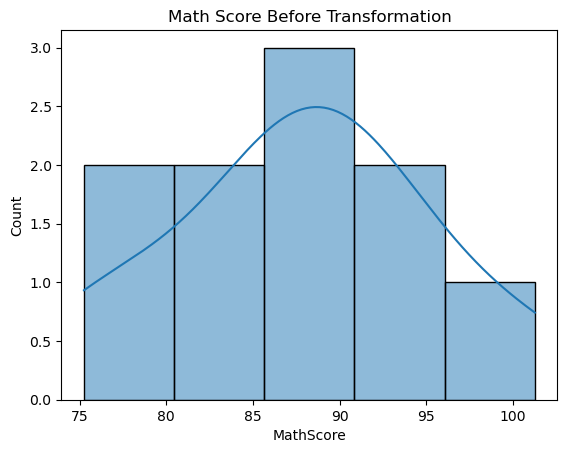

In [10]:
# Visualization
# ------------------------------
sns.histplot(df['MathScore'], kde=True)#Frequency distribution of data Kernel Density Estimation.
plt.title("Math Score Before Transformation")
plt.show()

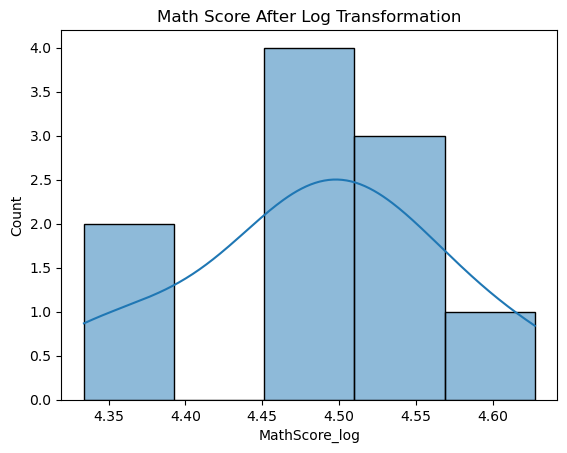

In [11]:
sns.histplot(df['MathScore_log'], kde=True)
plt.title("Math Score After Log Transformation")
plt.show()

In [12]:
print("\nFinal Dataset:\n", df)


Final Dataset:
    StudentID     Name     Age Gender  MathScore  EnglishScore  ScienceScore  \
0          1    Alice  15.000      F      85.00     78.000000     92.000000   
1          2      Bob  16.000      M      90.00     85.000000     88.000000   
2          3  Charlie  15.000      M      78.00     81.555556     85.000000   
3          4    David  16.000      M      92.00     80.000000     95.000000   
4          5      Eva  15.000      F      88.00     82.000000     90.000000   
5          6    Frank  15.625      M      75.25     77.000000     80.875000   
6          7    Grace  17.000      F      95.00     90.000000     93.000000   
7          8   Hannah  16.000      F      89.00     84.000000     87.000000   
8          9      Ian  15.625      M     101.25     70.000000     89.000000   
9         10     Jack  15.000      F      85.00     88.000000     88.555556   

   MathScore_log  
0       4.454347  
1       4.510860  
2       4.369448  
3       4.532599  
4       4.488636  